<a href="https://colab.research.google.com/github/tejaswipriya22/Tejaswi_Ml-on-big-data/blob/main/Week_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyspark

In [11]:
from pyspark.sql import SparkSession

# Initialize Spark Session
spark = SparkSession.builder \
    .appName("Customer Segmentation") \
    .getOrCreate()

print("Spark Session initialized successfully!")

Spark Session initialized successfully!


In [12]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

In [13]:
from google.colab import drive
drive.mount

<function google.colab.drive.mount(mountpoint, force_remount=False, timeout_ms=120000, readonly=False)>

In [14]:
# Load the customer segmentation dataset
# Assuming 'Segment' is the label column and other relevant columns are features
segmentation_df = spark.read.csv('/content/customer_segmentation_dataset.csv', inferSchema=True, header=True)

# Display schema and first few rows to understand the data
print("Schema of the Customer Segmentation Dataset:")
segmentation_df.printSchema()
print("\nFirst 5 rows of the Customer Segmentation Dataset:")
segmentation_df.show(5)

Schema of the Customer Segmentation Dataset:
root
 |-- age: integer (nullable = true)
 |-- annual_income: integer (nullable = true)
 |-- spending_score: integer (nullable = true)
 |-- years_as_customer: integer (nullable = true)
 |-- number_of_purchases: integer (nullable = true)
 |-- customer_segment: string (nullable = true)


First 5 rows of the Customer Segmentation Dataset:
+---+-------------+--------------+-----------------+-------------------+----------------+
|age|annual_income|spending_score|years_as_customer|number_of_purchases|customer_segment|
+---+-------------+--------------+-----------------+-------------------+----------------+
| 22|       113441|            19|                2|                 44|       Low Value|
| 47|        85415|            74|                7|                 11|    Medium Value|
| 60|        78075|            18|               19|                 37|       Low Value|
| 44|        89388|            84|               10|                 15|      

In [19]:
from pyspark.ml.feature import StringIndexer, VectorAssembler

# 1. Clean the data: Drop rows with NULL values
cleaned_df = segmentation_df.dropna()

# Identify columns
label_col = 'customer_segment'
feature_cols = [col for col in cleaned_df.columns if col not in ['CustomerID', label_col]]

processed_feature_cols = []
indexed_label_col = 'indexed' + label_col
current_df_for_indexing = cleaned_df

# Process categorical features with NULL handling
for col_name in feature_cols:
    if isinstance(current_df_for_indexing.schema[col_name].dataType, type('string')):
        indexer = StringIndexer(inputCol=col_name, outputCol=col_name + '_indexed', handleInvalid='skip')
        current_df_for_indexing = indexer.fit(current_df_for_indexing).transform(current_df_for_indexing)
        processed_feature_cols.append(col_name + '_indexed')
    else:
        processed_feature_cols.append(col_name)

# 2. Index the label with NULL handling
label_indexer = StringIndexer(inputCol=label_col, outputCol=indexed_label_col, handleInvalid='skip')
current_df_for_indexing = label_indexer.fit(current_df_for_indexing).transform(current_df_for_indexing)

# Assemble features
vector_assembler = VectorAssembler(inputCols=processed_feature_cols, outputCol="features")
prepared_df = vector_assembler.transform(current_df_for_indexing)

# Final DataFrame selection
final_df = prepared_df.select(indexed_label_col, "features")

print(f"Original row count: {segmentation_df.count()}")
print(f"Cleaned row count: {cleaned_df.count()}")
final_df.show(5)

Original row count: 585861
Cleaned row count: 585860

Schema after feature engineering:
root
 |-- indexedcustomer_segment: double (nullable = false)
 |-- features: vector (nullable = true)

+-----------------------+--------------------+
|indexedcustomer_segment|            features|
+-----------------------+--------------------+
|                    0.0|[22.0,113441.0,19...|
|                    1.0|[47.0,85415.0,74....|
|                    0.0|[60.0,78075.0,18....|
|                    2.0|[44.0,89388.0,84....|
|                    2.0|[37.0,94910.0,85....|
+-----------------------+--------------------+
only showing top 5 rows


In [20]:
# Split the data into training and test sets
(trainingData_segmentation, testData_segmentation) = final_df.randomSplit([0.7, 0.3], seed=42)

print(f"Training data count: {trainingData_segmentation.count()}")
print(f"Test data count: {testData_segmentation.count()}")

Training data count: 410121
Test data count: 175739


In [21]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize Decision Tree Classifier
dt_segmentation = DecisionTreeClassifier(
    labelCol=indexed_label_col,
    featuresCol="features",
    impurity='gini', # Using 'gini' as a common impurity measure
    maxDepth=5, # Limiting depth to avoid overfitting
    seed=42
)

# Train the Decision Tree model
model_dt_segmentation = dt_segmentation.fit(trainingData_segmentation)

# Make predictions on the test data
predictions_dt_segmentation = model_dt_segmentation.transform(testData_segmentation)

# Show some predictions
print("\nDecision Tree Predictions:")
predictions_dt_segmentation.select(indexed_label_col, "prediction", "features").show(5)

# Evaluate the model
evaluator_dt = MulticlassClassificationEvaluator(
    labelCol=indexed_label_col,
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy_dt = evaluator_dt.evaluate(predictions_dt_segmentation)
print(f"\nDecision Tree Test Accuracy: {accuracy_dt}")

# Print the Decision Tree model summary
print("\nDecision Tree Model Summary:")
print(model_dt_segmentation.toDebugString)


Decision Tree Predictions:
+-----------------------+----------+--------------------+
|indexedcustomer_segment|prediction|            features|
+-----------------------+----------+--------------------+
|                    0.0|       0.0|[18.0,20032.0,8.0...|
|                    0.0|       0.0|[18.0,20389.0,19....|
|                    0.0|       0.0|[18.0,20468.0,11....|
|                    0.0|       0.0|[18.0,20498.0,30....|
|                    0.0|       0.0|[18.0,20591.0,14....|
+-----------------------+----------+--------------------+
only showing top 5 rows

Decision Tree Test Accuracy: 0.9799816773738328

Decision Tree Model Summary:
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_d1aa5c4d1bd4, depth=2, numNodes=5, numClasses=3, numFeatures=5
  If (feature 2 <= 49.5)
   Predict: 0.0
  Else (feature 2 > 49.5)
   If (feature 2 <= 74.5)
    Predict: 1.0
   Else (feature 2 > 74.5)
    Predict: 2.0



In [22]:
from pyspark.ml.classification import LogisticRegression

# Initialize Logistic Regression Classifier
lr_segmentation = LogisticRegression(
    labelCol=indexed_label_col,
    featuresCol="features",
    maxIter=100,
    family="multinomial" # Explicitly set for multinomial logistic regression
)

# Train the Logistic Regression model
model_lr_segmentation = lr_segmentation.fit(trainingData_segmentation)

# Make predictions on the test data
predictions_lr_segmentation = model_lr_segmentation.transform(testData_segmentation)

# Show some predictions
print("\nLogistic Regression Predictions:")
predictions_lr_segmentation.select(indexed_label_col, "prediction", "features").show(5)

# Evaluate the model
evaluator_lr = MulticlassClassificationEvaluator(
    labelCol=indexed_label_col,
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy_lr = evaluator_lr.evaluate(predictions_lr_segmentation)
print(f"\nLogistic Regression Test Accuracy: {accuracy_lr}")


Logistic Regression Predictions:
+-----------------------+----------+--------------------+
|indexedcustomer_segment|prediction|            features|
+-----------------------+----------+--------------------+
|                    0.0|       0.0|[18.0,20032.0,8.0...|
|                    0.0|       0.0|[18.0,20389.0,19....|
|                    0.0|       0.0|[18.0,20468.0,11....|
|                    0.0|       0.0|[18.0,20498.0,30....|
|                    0.0|       0.0|[18.0,20591.0,14....|
+-----------------------+----------+--------------------+
only showing top 5 rows

Logistic Regression Test Accuracy: 1.0


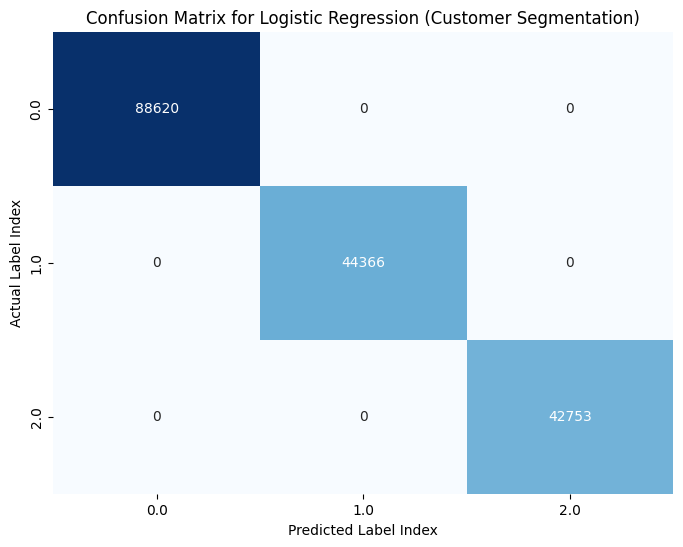

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert predictions and labels to Pandas DataFrame for easier manipulation
confusion_data = predictions_lr_segmentation.select(indexed_label_col, "prediction").toPandas()

# Create a confusion matrix using Pandas
confusion_matrix_df = pd.crosstab(
    confusion_data[indexed_label_col],
    confusion_data['prediction'],
    rownames=['Actual'],
    colnames=['Predicted']
)

# Plot the confusion matrix using Seaborn and Matplotlib
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Logistic Regression (Customer Segmentation)")
plt.xlabel("Predicted Label Index")
plt.ylabel("Actual Label Index")
plt.show()

In [35]:
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder

# 1. Clean the data: Drop rows with NULL values
cleaned_df = segmentation_df.dropna()

# Identify the label column
label_col = 'customer_segment'

# Identify potential feature columns (excluding 'CustomerID' and the label itself)
feature_cols = [col for col in cleaned_df.columns if col not in ['CustomerID', label_col]]

indexed_feature_cols = []
indexed_label_col = 'indexed' + label_col

current_df = cleaned_df

for col_name in feature_cols:
    if isinstance(current_df.schema[col_name].dataType, type('string')):
        # Added handleInvalid='skip' to manage any remaining nulls/unseen labels
        indexer = StringIndexer(inputCol=col_name, outputCol=col_name + '_indexed', handleInvalid='skip')
        current_df = indexer.fit(current_df).transform(current_df)
        indexed_feature_cols.append(col_name + '_indexed')
    else:
        # Otherwise, keep as is (assuming it's numeric)
        indexed_feature_cols.append(col_name)

# Index the label column
label_indexer = StringIndexer(inputCol=label_col, outputCol=indexed_label_col, handleInvalid='skip')
current_df = label_indexer.fit(current_df).transform(current_df)

# Assemble features into a single vector column
vector_assembler = VectorAssembler(
    inputCols=indexed_feature_cols,
    outputCol="features"
)
prepared_df = vector_assembler.transform(current_df)

# Select only the features and indexed label column
final_df = prepared_df.select(indexed_label_col, "features")

print(f"Original row count: {segmentation_df.count()}")
print(f"Cleaned row count: {cleaned_df.count()}")
print("\nSchema after feature engineering:")
final_df.printSchema()
final_df.show(5)

Original row count: 585861
Cleaned row count: 585860

Schema after feature engineering:
root
 |-- indexedcustomer_segment: double (nullable = false)
 |-- features: vector (nullable = true)

+-----------------------+--------------------+
|indexedcustomer_segment|            features|
+-----------------------+--------------------+
|                    0.0|[22.0,113441.0,19...|
|                    1.0|[47.0,85415.0,74....|
|                    0.0|[60.0,78075.0,18....|
|                    2.0|[44.0,89388.0,84....|
|                    2.0|[37.0,94910.0,85....|
+-----------------------+--------------------+
only showing top 5 rows


In [36]:
# Re-run the data split after correcting the label column
(trainingData_segmentation, testData_segmentation) = final_df.randomSplit([0.8, 0.3], seed=42)

print(f"Training data count: {trainingData_segmentation.count()}")
print(f"Test data count: {testData_segmentation.count()}")

Training data count: 426156
Test data count: 159704


In [37]:
# Re-run Decision Tree model training and evaluation
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize Decision Tree Classifier
dt_segmentation = DecisionTreeClassifier(
    labelCol=indexed_label_col,
    featuresCol="features",
    impurity='gini', # Using 'gini' as a common impurity measure
    maxDepth=5, # Limiting depth to avoid overfitting
    seed=42
)

# Train the Decision Tree model
model_dt_segmentation = dt_segmentation.fit(trainingData_segmentation)

# Make predictions on the test data
predictions_dt_segmentation = model_dt_segmentation.transform(testData_segmentation)

# Show some predictions
print("\nDecision Tree Predictions:")
predictions_dt_segmentation.select(indexed_label_col, "prediction", "features").show(5)

# Evaluate the model
evaluator_dt = MulticlassClassificationEvaluator(
    labelCol=indexed_label_col,
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy_dt = evaluator_dt.evaluate(predictions_dt_segmentation)
print(f"\nDecision Tree Test Accuracy: {accuracy_dt}")

# Print the Decision Tree model summary
print("\nDecision Tree Model Summary:")
print(model_dt_segmentation.toDebugString)


Decision Tree Predictions:
+-----------------------+----------+--------------------+
|indexedcustomer_segment|prediction|            features|
+-----------------------+----------+--------------------+
|                    0.0|       0.0|[18.0,20032.0,8.0...|
|                    0.0|       0.0|[18.0,20389.0,19....|
|                    0.0|       0.0|[18.0,20468.0,11....|
|                    0.0|       0.0|[18.0,20498.0,30....|
|                    0.0|       0.0|[18.0,20591.0,14....|
+-----------------------+----------+--------------------+
only showing top 5 rows

Decision Tree Test Accuracy: 0.9800631167660171

Decision Tree Model Summary:
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_2df39f42ba49, depth=2, numNodes=5, numClasses=3, numFeatures=5
  If (feature 2 <= 49.5)
   Predict: 0.0
  Else (feature 2 > 49.5)
   If (feature 2 <= 74.5)
    Predict: 1.0
   Else (feature 2 > 74.5)
    Predict: 2.0



In [38]:
# Re-run Logistic Regression model training and evaluation
from pyspark.ml.classification import LogisticRegression, OneVsRest

# Initialize Logistic Regression Classifier
lr_segmentation = LogisticRegression(
    labelCol=indexed_label_col,
    featuresCol="features",
    maxIter=100,
    family="multinomial" # Explicitly set for multinomial logistic regression
)

# Train the Logistic Regression model
model_lr_segmentation = lr_segmentation.fit(trainingData_segmentation)

# Make predictions on the test data
predictions_lr_segmentation = model_lr_segmentation.transform(testData_segmentation)

# Show some predictions
print("\nLogistic Regression Predictions:")
predictions_lr_segmentation.select(indexed_label_col, "prediction", "features").show(5)

# Evaluate the model
evaluator_lr = MulticlassClassificationEvaluator(
    labelCol=indexed_label_col,
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy_lr = evaluator_lr.evaluate(predictions_lr_segmentation)
print(f"\nLogistic Regression Test Accuracy: {accuracy_lr}")


Logistic Regression Predictions:
+-----------------------+----------+--------------------+
|indexedcustomer_segment|prediction|            features|
+-----------------------+----------+--------------------+
|                    0.0|       0.0|[18.0,20032.0,8.0...|
|                    0.0|       0.0|[18.0,20389.0,19....|
|                    0.0|       0.0|[18.0,20468.0,11....|
|                    0.0|       0.0|[18.0,20498.0,30....|
|                    0.0|       0.0|[18.0,20591.0,14....|
+-----------------------+----------+--------------------+
only showing top 5 rows

Logistic Regression Test Accuracy: 1.0


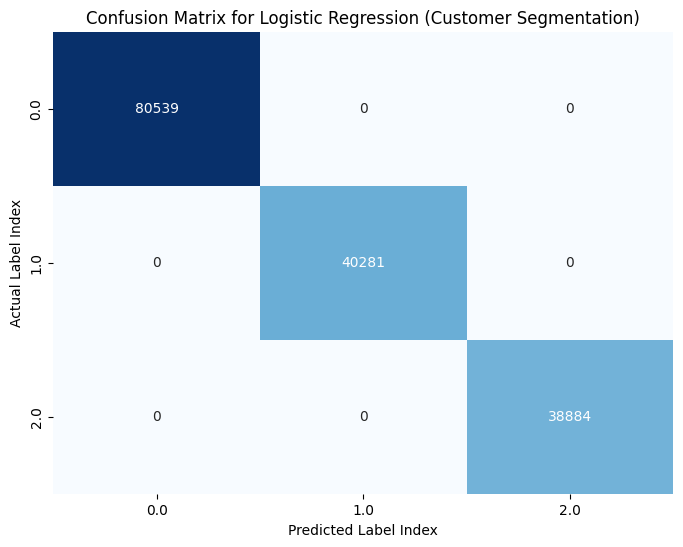

In [39]:
# Re-run Confusion Matrix generation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert predictions and labels to Pandas DataFrame for easier manipulation
confusion_data = predictions_lr_segmentation.select(indexed_label_col, "prediction").toPandas()

# Create a confusion matrix using Pandas
confusion_matrix_df = pd.crosstab(
    confusion_data[indexed_label_col],
    confusion_data['prediction'],
    rownames=['Actual'],
    colnames=['Predicted']
)

# Plot the confusion matrix using Seaborn and Matplotlib
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Logistic Regression (Customer Segmentation)")
plt.xlabel("Predicted Label Index")
plt.ylabel("Actual Label Index")
plt.show()

In [40]:
# Split the data into training and test sets
(trainingData_segmentation, testData_segmentation) = final_df.randomSplit([0.7, 0.3], seed=42)

print(f"Training data count: {trainingData_segmentation.count()}")
print(f"Test data count: {testData_segmentation.count()}")

Training data count: 410121
Test data count: 175739


In [41]:
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Initialize Decision Tree Classifier
dt_segmentation = DecisionTreeClassifier(
    labelCol=indexed_label_col,
    featuresCol="features",
    impurity='gini', # Using 'gini' as a common impurity measure
    maxDepth=5, # Limiting depth to avoid overfitting
    seed=42
)

# Train the Decision Tree model
model_dt_segmentation = dt_segmentation.fit(trainingData_segmentation)

# Make predictions on the test data
predictions_dt_segmentation = model_dt_segmentation.transform(testData_segmentation)

# Show some predictions
print("\nDecision Tree Predictions:")
predictions_dt_segmentation.select(indexed_label_col, "prediction", "features").show(5)

# Evaluate the model
evaluator_dt = MulticlassClassificationEvaluator(
    labelCol=indexed_label_col,
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy_dt = evaluator_dt.evaluate(predictions_dt_segmentation)
print(f"\nDecision Tree Test Accuracy: {accuracy_dt}")

# Print the Decision Tree model summary
print("\nDecision Tree Model Summary:")
print(model_dt_segmentation.toDebugString)


Decision Tree Predictions:
+-----------------------+----------+--------------------+
|indexedcustomer_segment|prediction|            features|
+-----------------------+----------+--------------------+
|                    0.0|       0.0|[18.0,20032.0,8.0...|
|                    0.0|       0.0|[18.0,20389.0,19....|
|                    0.0|       0.0|[18.0,20468.0,11....|
|                    0.0|       0.0|[18.0,20498.0,30....|
|                    0.0|       0.0|[18.0,20591.0,14....|
+-----------------------+----------+--------------------+
only showing top 5 rows

Decision Tree Test Accuracy: 0.9799816773738328

Decision Tree Model Summary:
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_4de1f6ac353b, depth=2, numNodes=5, numClasses=3, numFeatures=5
  If (feature 2 <= 49.5)
   Predict: 0.0
  Else (feature 2 > 49.5)
   If (feature 2 <= 74.5)
    Predict: 1.0
   Else (feature 2 > 74.5)
    Predict: 2.0



In [42]:
from pyspark.ml.classification import LogisticRegression, OneVsRest

# Initialize Logistic Regression Classifier
lr_segmentation = LogisticRegression(
    labelCol=indexed_label_col,
    featuresCol="features",
    maxIter=100,
    family="multinomial" # Explicitly set for multinomial logistic regression
)

# Train the Logistic Regression model
# Spark's LogisticRegression automatically handles multiclass classification (multinomial) when family='multinomial'
# For other cases, OneVsRest can be used explicitly.
model_lr_segmentation = lr_segmentation.fit(trainingData_segmentation)

# Make predictions on the test data
predictions_lr_segmentation = model_lr_segmentation.transform(testData_segmentation)

# Show some predictions
print("\nLogistic Regression Predictions:")
predictions_lr_segmentation.select(indexed_label_col, "prediction", "features").show(5)

# Evaluate the model
evaluator_lr = MulticlassClassificationEvaluator(
    labelCol=indexed_label_col,
    predictionCol="prediction",
    metricName="accuracy"
)
accuracy_lr = evaluator_lr.evaluate(predictions_lr_segmentation)
print(f"\nLogistic Regression Test Accuracy: {accuracy_lr}")


Logistic Regression Predictions:
+-----------------------+----------+--------------------+
|indexedcustomer_segment|prediction|            features|
+-----------------------+----------+--------------------+
|                    0.0|       0.0|[18.0,20032.0,8.0...|
|                    0.0|       0.0|[18.0,20389.0,19....|
|                    0.0|       0.0|[18.0,20468.0,11....|
|                    0.0|       0.0|[18.0,20498.0,30....|
|                    0.0|       0.0|[18.0,20591.0,14....|
+-----------------------+----------+--------------------+
only showing top 5 rows

Logistic Regression Test Accuracy: 1.0


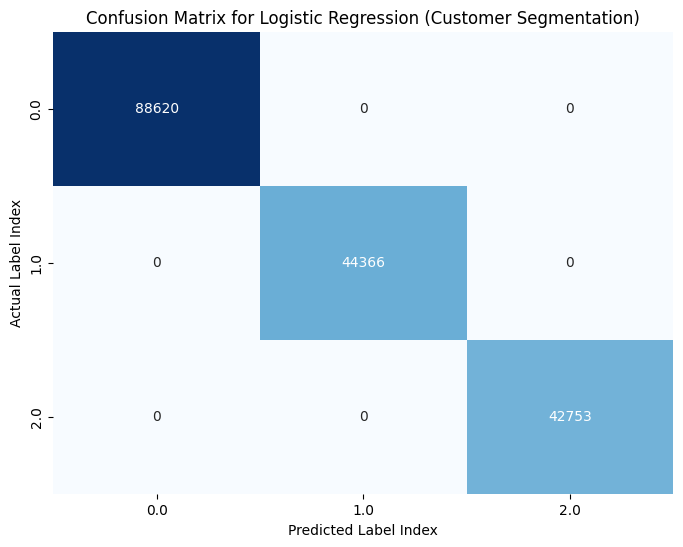

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Convert predictions and labels to Pandas DataFrame for easier manipulation
# Ensure to get original labels if needed for better readability in the confusion matrix
# For now, we use indexed labels, but ideally, we would map back to original string labels.
confusion_data = predictions_lr_segmentation.select(indexed_label_col, "prediction").toPandas()

# Create a confusion matrix using Pandas
confusion_matrix_df = pd.crosstab(
    confusion_data[indexed_label_col],
    confusion_data['prediction'],
    rownames=['Actual'],
    colnames=['Predicted']
)

# Plot the confusion matrix using Seaborn and Matplotlib
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix for Logistic Regression (Customer Segmentation)")
plt.xlabel("Predicted Label Index")
plt.ylabel("Actual Label Index")
plt.show()